In [1]:
# ============================================================
# Cell 1 — Imports + GPU Check
# ============================================================
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
from torchvision import transforms
from collections import defaultdict
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix
import pydicom
import pandas as pd
import timm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [2]:
# ============================================================
# Cell 2 — Load ADNI v2 Labels + Build Labeled Dataset
# ============================================================
ADNI_ROOT  = '/kaggle/input/datasets/mohinarustamova/neuroreach-adni-v2/neuroreach_adni_v2/ADNI'
CSV_PATH   = '/kaggle/input/datasets/mohinarustamova/neuroreach-adni-v2/neuroreach_adni_v2_6_25_2026.csv'
VIT_PATH   = '/kaggle/input/datasets/mohinarustamova/neuroreach-3class-weights/vit_3class_oasis.pth'
CORAL_PATH = '/kaggle/input/datasets/mohinarustamova/neuroreach-3class-weights/vit_3class_coral_adapted.pth'

CLASS_NAMES_3 = ['CN (Normal)', 'MCI', 'AD (Alzheimers)']
GROUP_MAP     = {'CN': 0, 'MCI': 1, 'AD': 2}

# Load labels
df = pd.read_csv(CSV_PATH)
subject_labels   = df[['Subject', 'Group']].drop_duplicates('Subject')
subject_to_label = {
    row['Subject']: GROUP_MAP[row['Group']]
    for _, row in subject_labels.iterrows()
}
print(f'Subjects with labels: {len(subject_to_label)}')
print(f'Distribution: {pd.Series(subject_to_label.values()).value_counts().to_dict()}')

# Collect DICOM files
adni_files  = []
subject_ids = []
for dcm_path in Path(ADNI_ROOT).rglob('*.dcm'):
    subject_id = dcm_path.parts[-5]
    adni_files.append(str(dcm_path))
    subject_ids.append(subject_id)

subject_to_files = defaultdict(list)
for path, subj in zip(adni_files, subject_ids):
    subject_to_files[subj].append(path)
for subj in subject_to_files:
    subject_to_files[subj].sort()

print(f'Total DICOM files : {len(adni_files)}')
print(f'Unique subjects   : {len(subject_to_files)}')

# Transforms
adni_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class ADNILabeledDataset(Dataset):
    def __init__(self, subject_to_files, subject_to_label,
                 slices_per_subject=20, transform=None):
        self.transform = transform
        self.samples   = []
        for subj, files in subject_to_files.items():
            if subj not in subject_to_label:
                continue
            label  = subject_to_label[subj]
            n      = len(files)
            start  = int(0.20 * n)
            end    = int(0.80 * n)
            usable = files[start:end]
            indices = np.linspace(0, len(usable) - 1, slices_per_subject, dtype=int)
            for i in indices:
                self.samples.append((usable[i], label))
        print(f'Total labeled samples: {len(self.samples)}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        dcm = pydicom.dcmread(path)
        img = dcm.pixel_array.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.stack([img, img, img], axis=0)
        img = torch.tensor(img, dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, label

# Build dataset
adni_full = ADNILabeledDataset(
    subject_to_files, subject_to_label,
    slices_per_subject=20, transform=adni_transforms
)
print(f'Dataset ready: {len(adni_full)} samples')

Subjects with labels: 122
Distribution: {1: 63, 0: 33, 2: 26}
Total DICOM files : 22960
Unique subjects   : 122
Total labeled samples: 2440
Dataset ready: 2440 samples


In [3]:
# ============================================================
# Cell 3 — Model Builder
# ============================================================

def build_vit(weights_path, unfreeze_blocks=2):
    vit = timm.create_model('vit_base_patch16_224', pretrained=False)
    vit.head = nn.Linear(vit.head.in_features, 3)
    vit.load_state_dict(torch.load(weights_path, map_location=device), strict=False)
    # Freeze all
    for param in vit.parameters():
        param.requires_grad = False
    # Unfreeze last N blocks + head
    for block in vit.blocks[-unfreeze_blocks:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in vit.head.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in vit.parameters() if p.requires_grad)
    return vit.to(device), trainable

# Test both load correctly
vit_test, params = build_vit(VIT_PATH)
print(f'ViT fine-tuned       — trainable params: {params:,}')
vit_test, params = build_vit(CORAL_PATH)
print(f'ViT+CORAL fine-tuned — trainable params: {params:,}')

ViT fine-tuned       — trainable params: 14,178,051
ViT+CORAL fine-tuned — trainable params: 14,178,051


In [4]:
# ============================================================
# Cell 4 — 5-Fold CV Function (Weighted Loss + Balanced Sampling)
# ============================================================
from torch.utils.data import WeightedRandomSampler

def run_kfold(weights_path, model_name, n_splits=5, epochs=20, lr=1e-4):
    kf      = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    indices = list(range(len(adni_full)))
    fold_accuracies = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(indices)):
        print(f'\n--- Fold {fold+1}/{n_splits} ---')

        # Balanced sampling — equal class representation per epoch
        train_labels   = [adni_full[i][1] for i in train_idx]
        class_counts   = np.bincount(train_labels)
        class_weights  = 1.0 / class_counts
        sample_weights = [class_weights[adni_full[i][1]] for i in train_idx]
        sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

        train_loader = DataLoader(adni_full, batch_size=16, sampler=sampler)
        test_loader  = DataLoader(adni_full, batch_size=16,
                                  sampler=SubsetRandomSampler(test_idx))

        model, _ = build_vit(weights_path)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # Weighted loss on top of balanced sampling
        cw = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=cw)
        print(f'  Class weights: CN={cw[0]:.4f} MCI={cw[1]:.4f} AD={cw[2]:.4f}')

        for epoch in range(epochs):
            model.train()
            correct, total = 0, 0
            for imgs, lbls in train_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                optimizer.zero_grad()
                outputs = model(imgs)
                loss    = criterion(outputs, lbls)
                loss.backward()
                optimizer.step()
                preds    = outputs.argmax(dim=1)
                correct += (preds == lbls).sum().item()
                total   += lbls.size(0)
            if (epoch + 1) % 5 == 0:
                print(f'  Epoch {epoch+1}/{epochs} Train Acc: {correct/total*100:.2f}%')

        # Evaluate
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs = imgs.to(device)
                outputs = model(imgs)
                preds   = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(lbls.numpy())

        acc = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
        fold_accuracies.append(acc)
        print(f'Fold {fold+1} Test Accuracy: {acc:.2f}%')

    print(f'\n=== {model_name} — 5-Fold CV Results ===')
    print(f'Per fold  : {[f"{a:.2f}%" for a in fold_accuracies]}')
    print(f'Mean      : {np.mean(fold_accuracies):.2f}%')
    print(f'Std       : {np.std(fold_accuracies):.2f}%')
    return fold_accuracies

print('run_kfold updated with balanced sampling!')

run_kfold updated with balanced sampling!


In [5]:
# ============================================================
# Cell 5 — Run ViT Fine-tuned on ADNI v2
# ============================================================
print('Running ViT fine-tuned on ADNI v2 (weighted loss)...')
accs_vit = run_kfold(VIT_PATH, 'ViT fine-tuned')

Running ViT fine-tuned on ADNI v2 (weighted loss)...

--- Fold 1/5 ---
  Class weights: CN=0.0019 MCI=0.0010 AD=0.0024
  Epoch 5/20 Train Acc: 89.81%
  Epoch 10/20 Train Acc: 96.98%
  Epoch 15/20 Train Acc: 96.31%
  Epoch 20/20 Train Acc: 97.85%
Fold 1 Test Accuracy: 88.73%

--- Fold 2/5 ---
  Class weights: CN=0.0019 MCI=0.0010 AD=0.0024
  Epoch 5/20 Train Acc: 89.50%
  Epoch 10/20 Train Acc: 95.80%
  Epoch 15/20 Train Acc: 97.28%
  Epoch 20/20 Train Acc: 98.82%
Fold 2 Test Accuracy: 86.89%

--- Fold 3/5 ---
  Class weights: CN=0.0019 MCI=0.0010 AD=0.0025
  Epoch 5/20 Train Acc: 88.88%
  Epoch 10/20 Train Acc: 94.57%
  Epoch 15/20 Train Acc: 96.16%
  Epoch 20/20 Train Acc: 99.39%
Fold 3 Test Accuracy: 87.09%

--- Fold 4/5 ---
  Class weights: CN=0.0019 MCI=0.0010 AD=0.0023
  Epoch 5/20 Train Acc: 91.19%
  Epoch 10/20 Train Acc: 97.59%
  Epoch 15/20 Train Acc: 99.23%
  Epoch 20/20 Train Acc: 98.26%
Fold 4 Test Accuracy: 84.84%

--- Fold 5/5 ---
  Class weights: CN=0.0019 MCI=0.0010 AD=

In [6]:
# ============================================================
# Cell 6 — ViT+CORAL Fine-tuned on ADNI v2
# ============================================================
print('Running ViT+CORAL fine-tuned on ADNI v2...')
accs_coral = run_kfold(CORAL_PATH, 'ViT+CORAL fine-tuned')

Running ViT+CORAL fine-tuned on ADNI v2...

--- Fold 1/5 ---
  Class weights: CN=0.0019 MCI=0.0010 AD=0.0024
  Epoch 5/20 Train Acc: 42.01%
  Epoch 10/20 Train Acc: 55.12%
  Epoch 15/20 Train Acc: 64.60%
  Epoch 20/20 Train Acc: 75.97%
Fold 1 Test Accuracy: 67.21%

--- Fold 2/5 ---
  Class weights: CN=0.0019 MCI=0.0010 AD=0.0024
  Epoch 5/20 Train Acc: 41.96%
  Epoch 10/20 Train Acc: 57.68%
  Epoch 15/20 Train Acc: 66.70%
  Epoch 20/20 Train Acc: 76.69%
Fold 2 Test Accuracy: 69.67%

--- Fold 3/5 ---
  Class weights: CN=0.0019 MCI=0.0010 AD=0.0025
  Epoch 5/20 Train Acc: 40.62%
  Epoch 10/20 Train Acc: 54.00%
  Epoch 15/20 Train Acc: 66.03%
  Epoch 20/20 Train Acc: 75.51%
Fold 3 Test Accuracy: 55.94%

--- Fold 4/5 ---
  Class weights: CN=0.0019 MCI=0.0010 AD=0.0023
  Epoch 5/20 Train Acc: 41.55%
  Epoch 10/20 Train Acc: 51.13%
  Epoch 15/20 Train Acc: 64.50%
  Epoch 20/20 Train Acc: 75.20%
Fold 4 Test Accuracy: 66.39%

--- Fold 5/5 ---
  Class weights: CN=0.0019 MCI=0.0010 AD=0.0024
  E

In [7]:
# ============================================================
# Cell 7 — Final Summary Table + Save Results
# ============================================================
import json

print('=' * 60)
print('NEUROREACH MODULE 1 — COMPLETE RESULTS')
print('=' * 60)
print(f'{"Model":<35} {"Dataset":<10} {"Accuracy"}')
print('-' * 60)
print(f'{"ResNet18":<35} {"OASIS":<10} 99.89%')
print(f'{"ViT 3-class":<35} {"OASIS":<10} 99.85%')
print(f'{"ResNet18 zero-shot":<35} {"ADNI":<10} 30.37%')
print(f'{"ViT+CORAL (4-class)":<35} {"ADNI":<10} 35.56%')
print(f'{"ViT fine-tuned (27 subj)":<35} {"ADNI":<10} 70.56% +/- 4.77%')
print(f'{"ViT fine-tuned (122 subj)":<35} {"ADNI":<10} {np.mean(accs_vit):.2f}% +/- {np.std(accs_vit):.2f}%')
print(f'{"ViT+CORAL fine-tuned (122 subj)":<35} {"ADNI":<10} {np.mean(accs_coral):.2f}% +/- {np.std(accs_coral):.2f}%')
print('=' * 60)

# Save results
results = {
    'resnet18_oasis'                   : 99.89,
    'vit_3class_oasis'                 : 99.85,
    'resnet18_adni_zeroshot'           : 30.37,
    'vit_coral_4class_adni'            : 35.56,
    'vit_finetuned_27subj_mean'        : 70.56,
    'vit_finetuned_27subj_std'         : 4.77,
    'vit_finetuned_122subj_mean'       : round(np.mean(accs_vit), 2),
    'vit_finetuned_122subj_std'        : round(np.std(accs_vit), 2),
    'vit_finetuned_122subj_folds'      : accs_vit,
    'vit_coral_finetuned_122subj_mean' : round(np.mean(accs_coral), 2),
    'vit_coral_finetuned_122subj_std'  : round(np.std(accs_coral), 2),
    'vit_coral_finetuned_122subj_folds': accs_coral,
}

with open('/kaggle/working/module1_results_final.json', 'w') as f:
    json.dump(results, f, indent=4)
print('\nResults saved to /kaggle/working/module1_results_final.json')

NEUROREACH MODULE 1 — COMPLETE RESULTS
Model                               Dataset    Accuracy
------------------------------------------------------------
ResNet18                            OASIS      99.89%
ViT 3-class                         OASIS      99.85%
ResNet18 zero-shot                  ADNI       30.37%
ViT+CORAL (4-class)                 ADNI       35.56%
ViT fine-tuned (27 subj)            ADNI       70.56% +/- 4.77%
ViT fine-tuned (122 subj)           ADNI       86.11% +/- 1.99%
ViT+CORAL fine-tuned (122 subj)     ADNI       64.02% +/- 4.96%

Results saved to /kaggle/working/module1_results_final.json


Epoch 5/20 Train Acc: 90.86%
Epoch 10/20 Train Acc: 96.19%
Epoch 15/20 Train Acc: 97.50%
Epoch 20/20 Train Acc: 99.39%
                 precision    recall  f1-score   support

    CN (Normal)       1.00      0.99      1.00       660
            MCI       0.99      0.99      0.99      1260
AD (Alzheimers)       0.99      0.99      0.99       520

       accuracy                           0.99      2440
      macro avg       0.99      0.99      0.99      2440
   weighted avg       0.99      0.99      0.99      2440



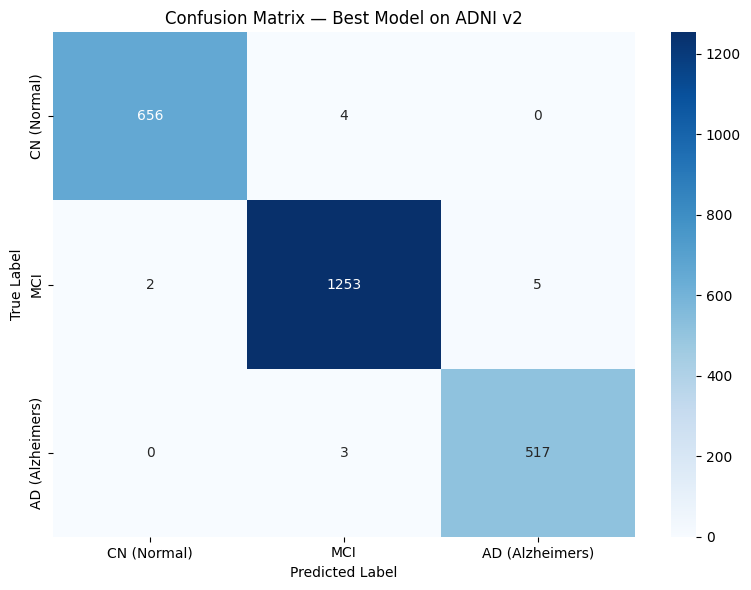

Best model saved!


In [8]:
# ============================================================
# Cell 8 — Confusion Matrix for Best Model
# ============================================================
# Run final evaluation with classification report
best_path = VIT_PATH  # update to CORAL_PATH if CORAL wins

model, _ = build_vit(best_path)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
class_counts  = np.bincount([adni_full[i][1] for i in range(len(adni_full))])
class_weights = 1.0 / class_counts
sample_weights = [class_weights[adni_full[i][1]] for i in range(len(adni_full))]
sampler   = WeightedRandomSampler(sample_weights, len(sample_weights))
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(device)
)
full_loader = DataLoader(adni_full, batch_size=16, sampler=sampler)

# Train on full dataset
for epoch in range(20):
    model.train()
    correct, total = 0, 0
    for imgs, lbls in full_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        preds    = outputs.argmax(dim=1)
        correct += (preds == lbls).sum().item()
        total   += lbls.size(0)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/20 Train Acc: {correct/total*100:.2f}%')

# Evaluate
model.eval()
all_preds, all_labels = [], []
test_loader = DataLoader(adni_full, batch_size=16, shuffle=False)
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES_3))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES_3, yticklabels=CLASS_NAMES_3)
plt.title('Confusion Matrix — Best Model on ADNI v2')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/best_model_confusion_matrix.png', dpi=150)
plt.show()

# Save best model
import torch
torch.save(model.state_dict(), '/kaggle/working/vit_best_adni.pth')
print('Best model saved!')